In [3]:
# ─── Cell 2: QAMMapper ────────────────────────────────────────────────────────

class QAMMapper:
    """
    Gray-coded QAM constellation mapper and hard-decision demapper.
    Supported: 'BPSK', 'QPSK', '16-QAM', '64-QAM'

    ── What is Gray Coding? ────────────────────────────────────────────────────
    Standard binary counting:  00, 01, 10, 11
    Gray code ordering:        00, 01, 11, 10

    In Gray code, adjacent values differ by exactly ONE bit.
    In QAM, "adjacent" means nearest neighbors in the I-Q plane.

    Why this matters for BER:
    When noise pushes a received symbol into the wrong decision region,
    it almost always lands in a *neighboring* region. Gray coding ensures
    that neighbor error = 1 bit error, not 2 or 3. Without Gray coding,
    BER at moderate SNR would be ~2× worse.

    ── Square QAM Structure ────────────────────────────────────────────────────
    For M-QAM (M = 4, 16, 64), we use two independent PAM signals:
      - MSBs (upper half of bits) → In-Phase (I, real axis)
      - LSBs (lower half of bits) → Quadrature (Q, imaginary axis)

    Each PAM dimension uses Gray-coded levels: {-3,-1,+1,+3} for 16-QAM.
    Normalization sets average symbol power = 1.0 across all schemes.
    """

    SCHEMES = ['BPSK', 'QPSK', '16-QAM', '64-QAM']
    COLORS  = {
        'BPSK':   '#5DCAA5',
        'QPSK':   '#378ADD',
        '16-QAM': '#EF9F27',
        '64-QAM': '#D85A30',
    }

    def __init__(self, scheme: str):
        if scheme not in self.SCHEMES:
            raise ValueError(f"scheme must be one of {self.SCHEMES}")
        self.scheme = scheme
        self._build_constellation()

    # ── Gray Code Utilities ──────────────────────────────────────────────────

    @staticmethod
    def _to_gray(n: int) -> int:
        """Natural binary → Gray code.  e.g. 3 (11) → 2 (10)"""
        return n ^ (n >> 1)

    @staticmethod
    def _from_gray(g: int) -> int:
        """
        Gray code → natural binary  (inverse of _to_gray).
        Used to find the PAM array index from a Gray-coded bit group.
        e.g. g=3 (11) → natural index 2
        """
        n, mask = g, g >> 1
        while mask:
            n    ^= mask
            mask >>= 1
        return n

    # ── Constellation Builder ────────────────────────────────────────────────

    def _build_constellation(self):
        """
        Generate the full  {bit_integer → complex_symbol}  lookup table.

        Algorithm for square M-QAM:
          1. Compute PAM levels for sqrt(M)-PAM: {-(√M-1), ..., +1, ..., +(√M-1)}
             e.g. √M=4 → [-3, -1, +1, +3]
          2. Measure average power per dimension → normalization factor
          3. For each of the M bit patterns:
               a. Split into k_half MSBs (→ I) and k_half LSBs (→ Q)
               b. Gray-decode each half to get the PAM array index
               c. Look up the PAM level, normalize, form complex symbol
        """
        if self.scheme == 'BPSK':
            self.bits_per_symbol = 1
            self.M               = 2
            self.norm_factor     = 1.0
            # Simple two-point BPSK: 0 → -1, 1 → +1 (on real axis)
            self.constellation   = {0: complex(-1, 0), 1: complex(+1, 0)}

        else:
            self.M               = 4 if self.scheme == 'QPSK' else int(self.scheme.split('-')[0])
            self.bits_per_symbol = int(np.log2(self.M))
            sqrt_M               = int(np.sqrt(self.M))
            k                    = self.bits_per_symbol // 2  # bits per axis

            # ── PAM levels for one dimension ─────────────────────────────
            # General formula: level_i = -(√M - 1) + 2i,  i = 0,1,...,√M-1
            # QPSK:   √M=2  → [-1, +1]
            # 16-QAM: √M=4  → [-3, -1, +1, +3]
            # 64-QAM: √M=8  → [-7, -5, -3, -1, +1, +3, +5, +7]
            pam_levels = [-(sqrt_M - 1) + 2 * i for i in range(sqrt_M)]

            # ── Normalization ─────────────────────────────────────────────
            # Average power per dim = E[level²]
            # Total avg power = 2 × per_dim  (I² + Q²)
            # We want total avg power = 1, so divide by √(2 × per_dim)
            avg_power_per_dim = np.mean([lv ** 2 for lv in pam_levels])
            self.norm_factor  = np.sqrt(2 * avg_power_per_dim)
            # Verification: norm_factor = √2 (QPSK), √10 (16-QAM), √42 (64-QAM)

            # ── Build table ───────────────────────────────────────────────
            self.constellation = {}
            for bit_int in range(self.M):

                # Split the bit integer: upper k bits → I, lower k bits → Q
                i_gray = (bit_int >> k) & ((1 << k) - 1)
                q_gray =  bit_int       & ((1 << k) - 1)

                # Gray decode → PAM array index
                # This maps the user's bit pattern to the correct PAM level
                # while preserving the Gray-code neighbor property
                i_idx  = self._from_gray(i_gray)
                q_idx  = self._from_gray(q_gray)

                I = pam_levels[i_idx]
                Q = pam_levels[q_idx]

                self.constellation[bit_int] = complex(I, Q) / self.norm_factor

        # ── Arrays for vectorized nearest-neighbor lookup ────────────────
        sorted_keys        = sorted(self.constellation.keys())
        self._sym_array    = np.array([self.constellation[k] for k in sorted_keys])
        self._key_array    = np.array(sorted_keys, dtype=int)

    # ── Modulation ───────────────────────────────────────────────────────────

    def modulate(self, bits: np.ndarray) -> np.ndarray:
        """
        Bit array → complex QAM symbol array.

        Steps per symbol:
          1. Grab the next `bits_per_symbol` bits
          2. Convert bit group to integer (MSB first)
          3. Look up complex symbol in the constellation table

        Args:
            bits: 1D int array (0/1). len(bits) must be divisible by bits_per_symbol.
        Returns:
            symbols: 1D complex array, length = len(bits) / bits_per_symbol.
        """
        bps = self.bits_per_symbol
        if len(bits) % bps != 0:
            raise ValueError(
                f"{self.scheme} needs bit count divisible by {bps}. "
                f"Got {len(bits)}. "
                f"Trim to {(len(bits) // bps) * bps} or pad with zeros."
            )

        n_syms  = len(bits) // bps
        symbols = np.empty(n_syms, dtype=complex)

        for i in range(n_syms):
            chunk   = bits[i * bps: (i + 1) * bps]
            # Convert bit array [b0, b1, ..., bn] → integer (b0 is MSB)
            bit_int = 0
            for b in chunk:
                bit_int = (bit_int << 1) | int(b)
            symbols[i] = self.constellation[bit_int]

        return symbols

    # ── Demodulation ─────────────────────────────────────────────────────────

    def demodulate(self, symbols: np.ndarray) -> np.ndarray:
        """
        Hard-decision nearest-neighbor QAM demodulation.

        For each received complex symbol r, find the constellation point c*
        that minimizes |r - c|².  Output the bit label of c*.

        "Hard decision" = we commit to a 0/1 immediately based on distance.
        (Phase 3 will eventually add soft decisions for LDPC decoding.)

        Vectorized using broadcasting: O(N_symbols × M) operations.
        """
        bps  = self.bits_per_symbol

        # ── Vectorized Euclidean distance ─────────────────────────────────
        # symbols:       (N,)  → reshape to (N, 1)
        # _sym_array:    (M,)  → broadcast to (N, M)
        # distances:     (N, M) — squared distance to every constellation point
        distances   = np.abs(symbols[:, np.newaxis] - self._sym_array[np.newaxis, :]) ** 2
        best_idx    = np.argmin(distances, axis=1)   # (N,) — index of nearest point
        bit_ints    = self._key_array[best_idx]      # (N,) — integer label

        # ── Unpack each integer to its bit representation ─────────────────
        bits = np.zeros(len(symbols) * bps, dtype=int)
        for i, bit_int in enumerate(bit_ints):
            for b in range(bps):
                bits[i * bps + b] = (int(bit_int) >> (bps - 1 - b)) & 1

        return bits

    # ── Utilities ─────────────────────────────────────────────────────────────

    def get_constellation_points(self):
        """Return (symbols, bit_labels) for all constellation points."""
        labels = [f"{k:0{self.bits_per_symbol}b}" for k in self._key_array]
        return self._sym_array.copy(), labels

    def __repr__(self):
        return (
            f"QAMMapper(scheme={self.scheme!r}, "
            f"bits_per_symbol={self.bits_per_symbol}, "
            f"M={self.M}, "
            f"norm_factor={self.norm_factor:.4f})"
        )


# ── Quick sanity check ────────────────────────────────────────────────────────
for s in QAMMapper.SCHEMES:
    m = QAMMapper(s)
    syms = m._sym_array
    avg_pwr = np.mean(np.abs(syms) ** 2)
    print(f"{s:<10}  bits/sym={m.bits_per_symbol}  M={m.M:>2}  "
          f"avg_power={avg_pwr:.6f}  (should be 1.0)")

BPSK        bits/sym=1  M= 2  avg_power=1.000000  (should be 1.0)
QPSK        bits/sym=2  M= 4  avg_power=1.000000  (should be 1.0)
16-QAM      bits/sym=4  M=16  avg_power=1.000000  (should be 1.0)
64-QAM      bits/sym=6  M=64  avg_power=1.000000  (should be 1.0)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import time

assert 'QAMMapper' in dir(), "run Phase 2 cells first"

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f", "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444", "axes.labelcolor": "#ccc",
    "xtick.color": "#888", "ytick.color": "#888", "text.color": "#eee",
    "grid.color": "#2a2a2a", "grid.linestyle": "--", "grid.alpha": 0.5,
})

In [5]:
def theoretical_ber(scheme, snr_db_arr):
    """Gray-coded square M-QAM BER over AWGN, in terms of Es/N0 (snr_db_arr)."""
    mapper = QAMMapper(scheme)
    M, k = mapper.M, mapper.bits_per_symbol
    snr_lin = 10 ** (snr_db_arr / 10)
    EbN0 = snr_lin / k

    if scheme in ('BPSK', 'QPSK'):
        return 0.5 * erfc(np.sqrt(EbN0))
    sqrt_M = np.sqrt(M)
    return (4 / k) * (1 - 1 / sqrt_M) * 0.5 * erfc(np.sqrt(3 * k * EbN0 / (2 * (M - 1))))


def mc_ber_qam(scheme, snr_db_arr, n_symbols=20000, seed=0):
    """
    Monte Carlo BER for one scheme across an SNR sweep.
    n_symbols per point, fixed seed per point (not per call) so points
    are independent draws, not the same noise sequence reused.
    """
    mapper = QAMMapper(scheme)
    bps = mapper.bits_per_symbol
    ber = np.zeros(len(snr_db_arr))

    for i, snr_db in enumerate(snr_db_arr):
        rng = np.random.default_rng(seed * 1000 + i)
        bits = rng.integers(0, 2, n_symbols * bps)
        tx = mapper.modulate(bits)

        sig_power = np.mean(np.abs(tx) ** 2)
        noise_power = sig_power / (10 ** (snr_db / 10))
        noise = np.sqrt(noise_power / 2) * (
            rng.standard_normal(n_symbols) + 1j * rng.standard_normal(n_symbols)
        )
        rx = tx + noise

        rx_bits = mapper.demodulate(rx)
        ber[i] = np.sum(bits != rx_bits) / len(bits)

    return ber


# sweep
snr_db_arr = np.linspace(0, 30, 16)
schemes = ['BPSK', 'QPSK', '16-QAM']
n_symbols = 20000  # >10k per point per the task

mc_results = {}
t0 = time.time()
for scheme in schemes:
    mc_results[scheme] = mc_ber_qam(scheme, snr_db_arr, n_symbols=n_symbols, seed=1)
    print(f"{scheme}: done")
print(f"total time: {time.time()-t0:.1f}s")

BPSK: done
QPSK: done
16-QAM: done
total time: 2.9s


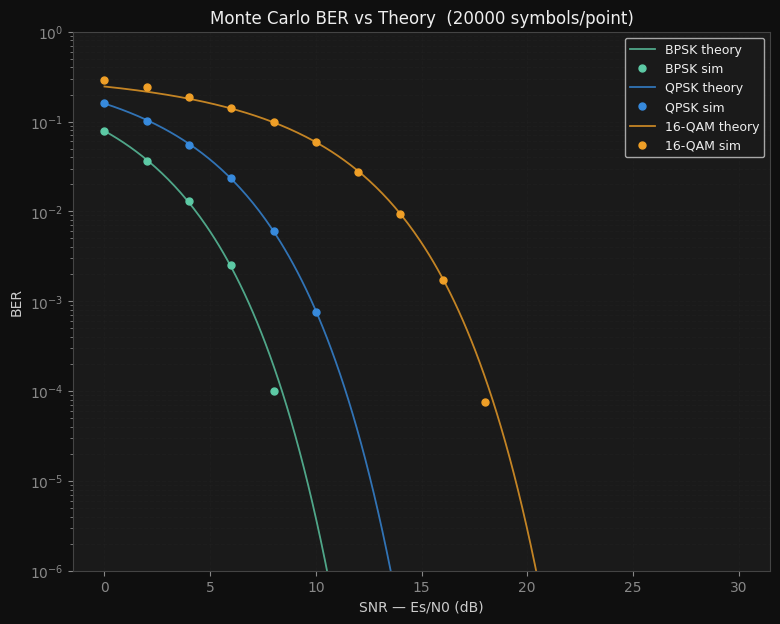

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = {'BPSK': '#5DCAA5', 'QPSK': '#378ADD', '16-QAM': '#EF9F27'}

snr_fine = np.linspace(0, 30, 300)

for scheme in schemes:
    c = colors[scheme]
    ax.semilogy(snr_fine, theoretical_ber(scheme, snr_fine),
                color=c, lw=1.3, ls='-', alpha=0.8, label=f'{scheme} theory')
    ax.semilogy(snr_db_arr, mc_results[scheme],
                color=c, marker='o', ls='none', markersize=5, label=f'{scheme} sim')

ax.set_ylim(1e-6, 1)
ax.set_xlabel('SNR — Es/N0 (dB)')
ax.set_ylabel('BER')
ax.set_title(f'Monte Carlo BER vs Theory  ({n_symbols} symbols/point)')
ax.grid(True, which='both', alpha=0.2)
ax.legend(fontsize=9)
plt.savefig('mc_ber_vs_theory.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

In [7]:
def find_snr_threshold(scheme, target_ber=1e-3, snr_search=None):
    """Lowest SNR at which theoretical BER drops to target_ber."""
    if snr_search is None:
        snr_search = np.linspace(0, 35, 7000)
    ber = theoretical_ber(scheme, snr_search)
    below = ber <= target_ber
    if not below.any():
        return np.inf
    return snr_search[np.argmax(below)]


def build_adaptive_table(target_ber=1e-3):
    """SNR threshold per scheme, sorted ascending by required SNR."""
    table = []
    for scheme in ['BPSK', 'QPSK', '16-QAM', '64-QAM']:
        thresh = find_snr_threshold(scheme, target_ber)
        bps = QAMMapper(scheme).bits_per_symbol
        table.append((scheme, thresh, bps))
    return sorted(table, key=lambda x: x[1])


def select_modulation(snr_db, adaptive_table):
    """
    Pick the highest-throughput scheme whose SNR threshold is <= measured SNR.
    adaptive_table must be sorted ascending by threshold.
    """
    chosen = adaptive_table[0][0]  # fallback: most robust scheme
    for scheme, thresh, bps in adaptive_table:
        if snr_db >= thresh:
            chosen = scheme
    return chosen


target = 1e-3
table = build_adaptive_table(target)
print(f"Adaptive thresholds for target BER = {target}:")
for scheme, thresh, bps in table:
    print(f"  {scheme:<8}  SNR >= {thresh:5.1f} dB  ->  {bps} bits/symbol")

# test it
for snr_test in [3, 9, 14, 18, 24, 30]:
    print(f"SNR={snr_test:>3} dB  ->  {select_modulation(snr_test, table)}")

Adaptive thresholds for target BER = 0.001:
  BPSK      SNR >=   6.8 dB  ->  1 bits/symbol
  QPSK      SNR >=   9.8 dB  ->  2 bits/symbol
  16-QAM    SNR >=  16.5 dB  ->  4 bits/symbol
  64-QAM    SNR >=  22.6 dB  ->  6 bits/symbol
SNR=  3 dB  ->  BPSK
SNR=  9 dB  ->  BPSK
SNR= 14 dB  ->  QPSK
SNR= 18 dB  ->  16-QAM
SNR= 24 dB  ->  64-QAM
SNR= 30 dB  ->  64-QAM


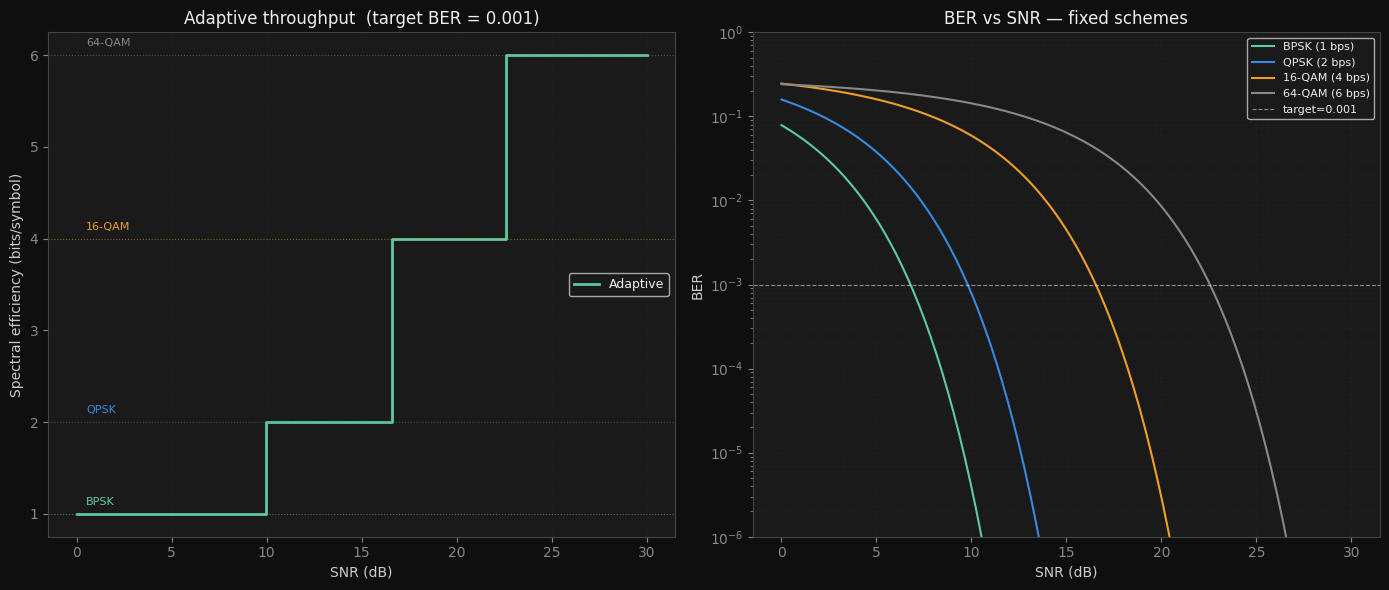

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# left: throughput staircase of the adaptive scheme vs fixed schemes
snr_range = np.linspace(0, 30, 200)
adaptive_bps = np.array([
    QAMMapper(select_modulation(s, table)).bits_per_symbol for s in snr_range
])

ax1.step(snr_range, adaptive_bps, where='post', color='#5DCAA5', lw=2, label='Adaptive')
for scheme in ['BPSK', 'QPSK', '16-QAM', '64-QAM']:
    bps = QAMMapper(scheme).bits_per_symbol
    ax1.axhline(bps, color=colors.get(scheme, '#888'), lw=0.8, ls=':', alpha=0.5)
    ax1.annotate(scheme, xy=(0.5, bps + 0.1), fontsize=8, color=colors.get(scheme, '#888'))

ax1.set_xlabel('SNR (dB)')
ax1.set_ylabel('Spectral efficiency (bits/symbol)')
ax1.set_title(f'Adaptive throughput  (target BER = {target})')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)

# right: throughput vs achieved BER tradeoff — fixed schemes only
for scheme in ['BPSK', 'QPSK', '16-QAM', '64-QAM']:
    bps = QAMMapper(scheme).bits_per_symbol
    ber = theoretical_ber(scheme, snr_range)
    ax2.semilogy(snr_range, ber, color=colors.get(scheme, '#888'), lw=1.5,
                 label=f'{scheme} ({bps} bps)')
ax2.axhline(target, color='white', lw=0.8, ls='--', alpha=0.5, label=f'target={target}')
ax2.set_xlabel('SNR (dB)')
ax2.set_ylabel('BER')
ax2.set_ylim(1e-6, 1)
ax2.set_title('BER vs SNR — fixed schemes')
ax2.legend(fontsize=8)
ax2.grid(True, which='both', alpha=0.2)

plt.tight_layout()
plt.savefig('spectral_efficiency_tradeoff.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

coding gain at BER=0.001: 0.08 dB
coding gain at BER=0.0001: 0.16 dB
coding gain at BER=1e-05: 0.28 dB


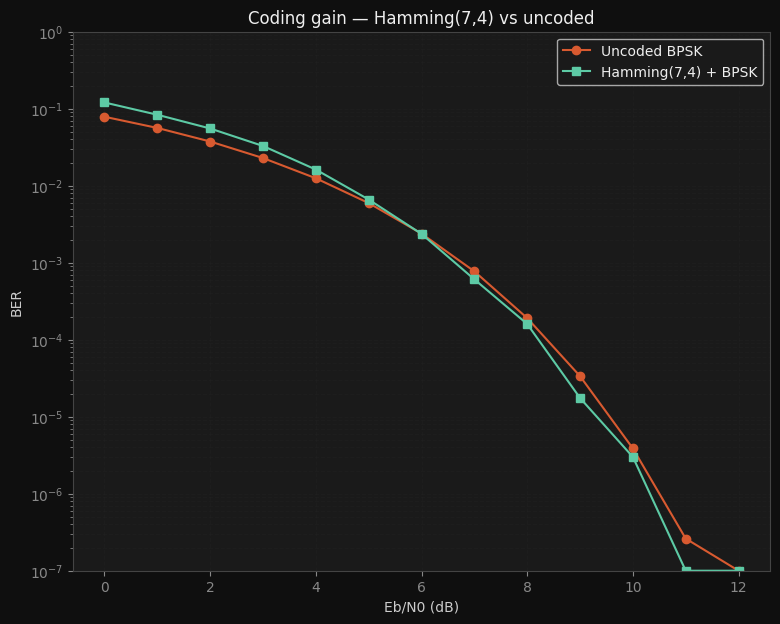

crossover point: 5.97 dB  (coding hurts below this, helps above it)
coding gain at BER=0.001: 0.08 dB
coding gain at BER=0.0001: 0.16 dB
coding gain at BER=1e-05: 0.28 dB


In [12]:
# systematic Hamming(7,4): G = [I4 | P], H = [P^T | I3]
G = np.array([
    [1,0,0,0, 1,1,0],
    [0,1,0,0, 1,0,1],
    [0,0,1,0, 0,1,1],
    [0,0,0,1, 1,1,1],
]) % 2

H = np.array([
    [1,1,0,1, 1,0,0],
    [1,0,1,1, 0,1,0],
    [0,1,1,1, 0,0,1],
]) % 2

assert np.all((G @ H.T) % 2 == 0), "G/H mismatch"

SYNDROME_TABLE = {}
for col_idx in range(7):
    syndrome = tuple(H[:, col_idx])
    SYNDROME_TABLE[syndrome] = col_idx


def hamming_encode(data_bits):
    """data_bits: (n, 4) -> codewords (n, 7)"""
    return (data_bits @ G) % 2


def hamming_decode(received_bits):
    """received_bits: (n, 7) -> corrected data bits (n, 4). Corrects 1 error/block."""
    n = received_bits.shape[0]
    corrected = received_bits.copy()
    syndromes = (received_bits @ H.T) % 2

    for i in range(n):
        s = tuple(syndromes[i])
        if s != (0, 0, 0) and s in SYNDROME_TABLE:
            corrected[i, SYNDROME_TABLE[s]] ^= 1

    return corrected[:, :4]


def coded_ber_vs_ebn0_v2(ebno_db_arr, base_blocks=50000, seed=2):
    """
    Hamming(7,4) over BPSK/AWGN (BSC model), compared at fixed Eb/N0.
    Code rate R = 4/7 -> coded bits get less energy each for the same Eb,
    so crossover prob uses Ec/N0 = R * Eb/N0.

    Block count scales up with SNR so the high-SNR tail isn't running
    on single-digit error counts (which is what made the earlier plot noisy).
    """
    R = 4 / 7
    rng = np.random.default_rng(seed)
    coded_ber = np.zeros(len(ebno_db_arr))
    uncoded_ber = np.zeros(len(ebno_db_arr))

    for i, ebno_db in enumerate(ebno_db_arr):
        n_blocks = base_blocks * max(1, int(2 ** (ebno_db / 4)))

        ebno_lin = 10 ** (ebno_db / 10)
        uncoded_ber[i] = 0.5 * erfc(np.sqrt(ebno_lin))

        ecno_lin = R * ebno_lin
        p_flip = 0.5 * erfc(np.sqrt(ecno_lin))

        data = rng.integers(0, 2, (n_blocks, 4))
        codewords = hamming_encode(data)

        flips = rng.random(codewords.shape) < p_flip
        received = codewords ^ flips.astype(int)

        decoded = hamming_decode(received)
        coded_ber[i] = np.sum(decoded != data) / data.size

    return coded_ber, uncoded_ber


def find_crossover(coded_ber, uncoded_ber, snr_arr):
    """SNR where coded transitions from worse to better than uncoded."""
    diff = coded_ber - uncoded_ber  # positive = coded worse
    sign_change = np.where(np.diff(np.sign(diff)) < 0)[0]
    if len(sign_change) == 0:
        return None
    i = sign_change[0]
    x0, x1 = snr_arr[i], snr_arr[i+1]
    y0, y1 = diff[i], diff[i+1]
    return x0 - y0 * (x1 - x0) / (y1 - y0)


def gain_at_target_robust(coded_ber, uncoded_ber, snr_arr, target):
    """
    Forces monotonic non-increasing BER vs SNR by taking a running minimum
    in the direction of increasing SNR — clamps upward MC noise blips to the
    best BER already achieved at any lower SNR, without distorting the trend.
    """
    coded_smooth   = np.minimum.accumulate(coded_ber)
    uncoded_smooth = np.minimum.accumulate(uncoded_ber)

    # np.interp needs ascending xp — reverse since BER is now non-increasing in SNR
    snr_coded   = np.interp(target, coded_smooth[::-1],   snr_arr[::-1])
    snr_uncoded = np.interp(target, uncoded_smooth[::-1], snr_arr[::-1])
    return snr_uncoded - snr_coded


for target in [1e-3, 1e-4, 1e-5]:
    g = gain_at_target_robust(coded_ber, uncoded_ber, ebno_db_arr, target)
    print(f"coding gain at BER={target}: {g:.2f} dB")


# ── Run ──────────────────────────────────────────────────────────────────────
ebno_db_arr = np.linspace(0, 12, 13)
coded_ber, uncoded_ber = coded_ber_vs_ebn0_v2(ebno_db_arr, base_blocks=50000)

fig, ax = plt.subplots(figsize=(9, 7))
ax.semilogy(ebno_db_arr, np.maximum(uncoded_ber, 1e-7), 'o-', color='#D85A30', label='Uncoded BPSK')
ax.semilogy(ebno_db_arr, np.maximum(coded_ber, 1e-7), 's-', color='#5DCAA5', label='Hamming(7,4) + BPSK')
ax.set_xlabel('Eb/N0 (dB)')
ax.set_ylabel('BER')
ax.set_ylim(1e-7, 1)
ax.set_title('Coding gain — Hamming(7,4) vs uncoded')
ax.legend()
ax.grid(True, which='both', alpha=0.2)
plt.savefig('hamming_coding_gain.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# ── Report ────────────────────────────────────────────────────────────────────
crossover = find_crossover(coded_ber, uncoded_ber, ebno_db_arr)
if crossover is not None:
    print(f"crossover point: {crossover:.2f} dB  (coding hurts below this, helps above it)")
else:
    print("no crossover found in this SNR range")

for target in [1e-3, 1e-4, 1e-5]:
    g = gain_at_target_robust(coded_ber, uncoded_ber, ebno_db_arr, target)
    print(f"coding gain at BER={target}: {g:.2f} dB")